# 范哲齐-25361077-第三次作业运行结果

**分析主题：** 公交 IC 卡刷卡数据分析  
**使用库：** NumPy、pandas、matplotlib、seaborn

本 Notebook 包含六项任务的完整代码、打印结果和三张可视化图。

In [1]:
%matplotlib inline
"""《人工智能编程语言》第三次作业：公交 IC 卡刷卡数据分析。

姓名：范哲齐
学号：25361077
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "ICData.csv").exists():
    candidate = PROJECT_DIR / "范哲齐-25361077-第三次人工智能编程作业"
    if candidate.exists():
        PROJECT_DIR = candidate
DATA_FILE = PROJECT_DIR / "ICData.csv"


def print_task_title(number, title):
    """打印统一的任务分隔标题。"""
    print("\n" + "=" * 72)
    print(f"任务{number}  {title}")
    print("=" * 72)




## 任务1：数据预处理

In [2]:
def load_and_preprocess(csv_path=DATA_FILE):
    """读取 IC 卡数据，完成时间解析、衍生字段构造和异常值清理。"""
    print_task_title(1, "数据预处理")

    # 使用 utf-8-sig 自动处理 CSV 表头可能带有的 BOM 字符。
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    print("数据集前5行：")
    print(df.head().to_string(index=False))
    print(f"\n基本信息：{df.shape[0]} 行，{df.shape[1]} 列")
    print("各列初始数据类型：")
    print(df.dtypes.to_string())

    # errors='coerce' 会把无法解析的时间置为 NaT，便于后续统一当作缺失值处理。
    df["交易时间"] = pd.to_datetime(df["交易时间"], errors="coerce")
    # dt.hour 从每个 datetime 中提取 0~23 的小时整数。
    df["hour"] = df["交易时间"].dt.hour

    # 下车站点与上车站点之差取绝对值，得到搭乘站点数。
    df["ride_stops"] = (df["下车站点"] - df["上车站点"]).abs()
    zero_stop_mask = df["ride_stops"].eq(0)
    deleted_zero_stops = int(zero_stop_mask.sum())
    df = df.loc[~zero_stop_mask].copy()
    print(f"\n删除 ride_stops=0 的异常记录：{deleted_zero_stops} 行")

    print("各列缺失值数量：")
    print(df.isna().sum().to_string())
    before_dropna = len(df)
    df = df.dropna().copy()
    deleted_missing = before_dropna - len(df)
    print(f"删除含缺失值的记录：{deleted_missing} 行")

    # 缺失值已删除，将小时列转回普通整数，便于 NumPy 统计和绘图。
    df["hour"] = df["hour"].astype(int)
    print(f"预处理后有效记录：{len(df)} 行")
    return df




df = load_and_preprocess()


任务1  数据预处理
数据集前5行：
 交易类型              交易时间     交易卡号  刷卡类型  线路号  车辆编号  上车站点  下车站点  驾驶员编号   运营公司编号
    6 2018/4/1 11:45:12  4315305     0 1101  9132    28    19 1599.0 75170100
    6 2018/4/1 10:14:52 38248936     0 1117  2026    11    15 1590.0 75170100
    6  2018/4/1 7:25:47 15346972     0 1106  9044    22    19 1987.0 75170100
    6 2018/4/1 20:15:09 52881250     0 1112  9060    39    14  101.0 75170100
    6 2018/4/1 11:44:36 18941532     0 1101  9130    42    18   41.0 75170100

基本信息：200000 行，10 列
各列初始数据类型：
交易类型        int64
交易时间       object
交易卡号        int64
刷卡类型        int64
线路号         int64
车辆编号        int64
上车站点        int64
下车站点        int64
驾驶员编号     float64
运营公司编号      int64

删除 ride_stops=0 的异常记录：40886 行
各列缺失值数量：
交易类型          0
交易时间          0
交易卡号          0
刷卡类型          0
线路号           0
车辆编号          0
上车站点          0
下车站点          0
驾驶员编号         0
运营公司编号        0
hour          0
ride_stops    0
删除含缺失值的记录：0 行
预处理后有效记录：159114 行


## 任务2：时间分布分析


任务2  时间分布分析
全天上车刷卡量：159113 次
早峰前时段（hour < 7）：3188 次，占比 2.00%
深夜时段（hour >= 22）：1660 次，占比 1.04%


24小时分布图已保存：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/hour_distribution.png


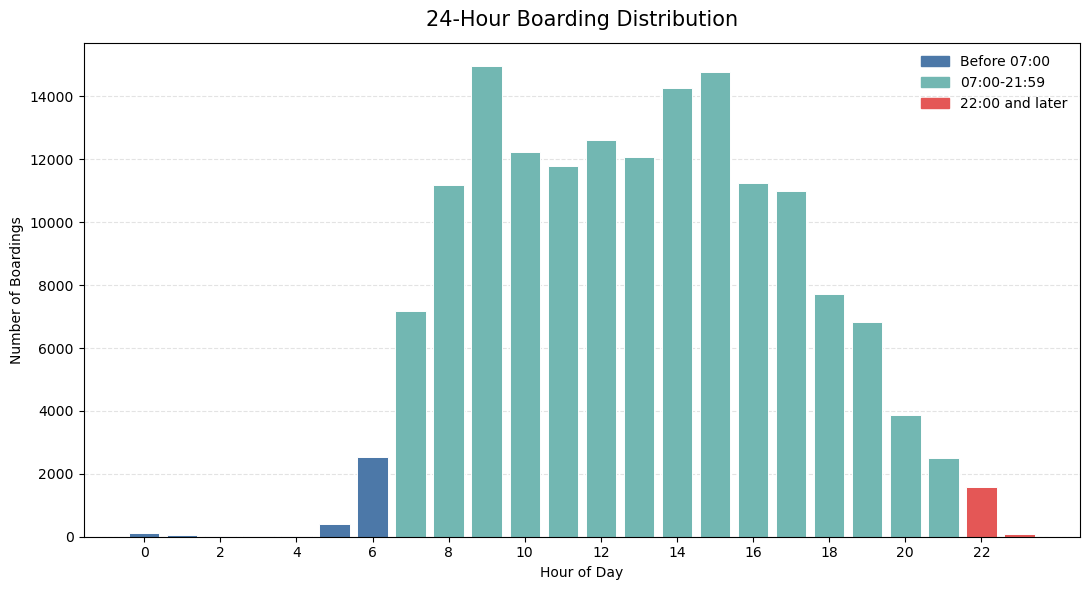

In [3]:
def analyze_time_distribution(df):
    """使用 NumPy 统计特定时段，并绘制 24 小时刷卡量柱状图。"""
    print_task_title(2, "时间分布分析")

    boardings = df.loc[df["刷卡类型"].eq(0)].copy()
    hours = boardings["hour"].to_numpy(dtype=int)

    # 通过 NumPy 布尔索引选出早峰前与深夜的小时值，再用元素数量得到刷卡量。
    early_hours = hours[hours < 7]
    late_hours = hours[hours >= 22]
    early_count = int(early_hours.size)
    late_count = int(late_hours.size)
    total_count = int(hours.size)

    early_pct = early_count / total_count * 100 if total_count else 0.0
    late_pct = late_count / total_count * 100 if total_count else 0.0
    print(f"全天上车刷卡量：{total_count} 次")
    print(f"早峰前时段（hour < 7）：{early_count} 次，占比 {early_pct:.2f}%")
    print(f"深夜时段（hour >= 22）：{late_count} 次，占比 {late_pct:.2f}%")

    # bincount 直接对 0~23 的小时整数计数，minlength 确保无数据的小时也保留。
    hourly_counts = np.bincount(hours, minlength=24)[:24]
    hour_values = np.arange(24)
    bar_colors = np.where(
        hour_values < 7,
        "#4C78A8",
        np.where(hour_values >= 22, "#E45756", "#72B7B2"),
    )

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(hour_values, hourly_counts, color=bar_colors, edgecolor="white", linewidth=0.7)
    ax.set_title("24-Hour Boarding Distribution", fontsize=15, pad=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Number of Boardings")
    ax.set_xticks(np.arange(0, 24, 2))
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    from matplotlib.patches import Patch

    ax.legend(
        handles=[
            Patch(color="#4C78A8", label="Before 07:00"),
            Patch(color="#72B7B2", label="07:00-21:59"),
            Patch(color="#E45756", label="22:00 and later"),
        ],
        frameon=False,
    )
    fig.tight_layout()
    output_path = PROJECT_DIR / "hour_distribution.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"24小时分布图已保存：{output_path}")
    plt.show()
    plt.close(fig)
    return boardings, hourly_counts




boardings, hourly_counts = analyze_time_distribution(df)

## 任务3：线路站点分析


任务3  线路站点分析
各线路搭乘站点数统计（前10行）：
  线路号  mean_stops  std_stops
  125     15.8182     8.8184
51020     14.1158     7.1308
 1112     12.4515     9.6554
52020     12.1371     6.5490
   71     11.0000     6.9282
 1113     10.3022     8.5333
 1101     10.0769     9.1874
    3      9.9788     8.2718
 1201      9.4196     8.0215
46002      9.3917     4.2998


线路站点分析图已保存：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/route_stops.png


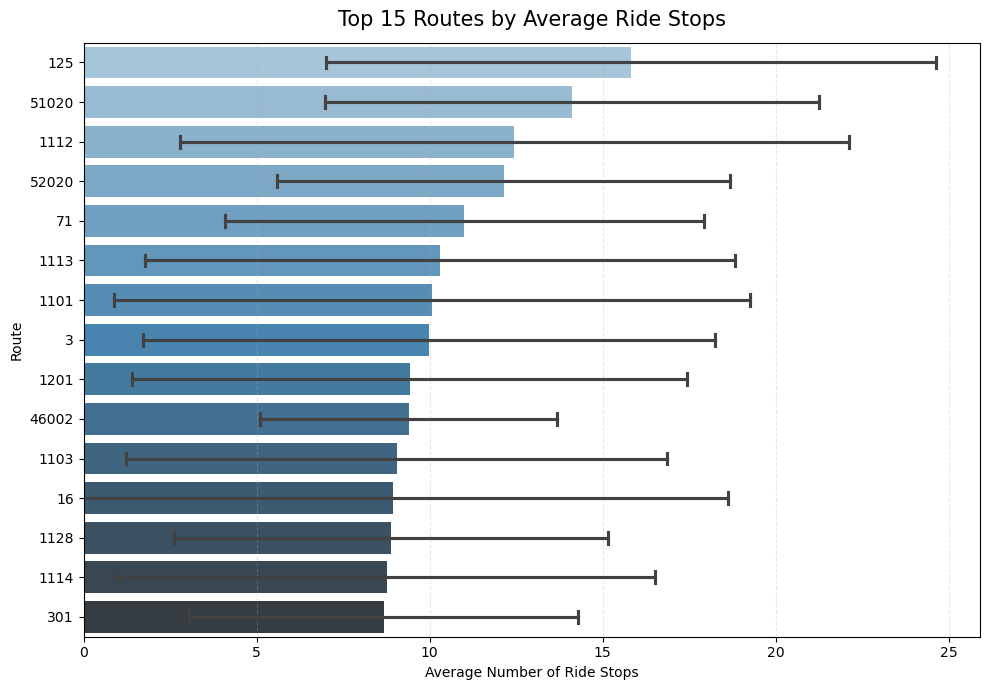

In [4]:
def analyze_route_stops(df, route_col='线路号', stops_col='ride_stops'):
    """
    计算各线路乘客的平均搭乘站点数及其标准差。
    Parameters
    ----------
    df : pd.DataFrame  预处理后的数据集
    route_col : str    线路号列名
    stops_col : str    搭乘站点数列名
    Returns
    -------
    pd.DataFrame  包含列：线路号、mean_stops、std_stops，按 mean_stops 降序排列
    """
    route_stats = (
        df.groupby(route_col, as_index=False)[stops_col]
        .agg(mean_stops="mean", std_stops="std")
        .sort_values("mean_stops", ascending=False)
        .reset_index(drop=True)
    )
    # 若某条线路只有1条记录，样本标准差为 NaN，此时按 0 处理便于绘制误差棒。
    route_stats["std_stops"] = route_stats["std_stops"].fillna(0.0)
    return route_stats


def plot_route_stops(boardings):
    """打印线路统计结果，并使用 seaborn 绘制均值最高的前15条线路。"""
    print_task_title(3, "线路站点分析")
    route_stats = analyze_route_stops(boardings)
    print("各线路搭乘站点数统计（前10行）：")
    print(route_stats.head(10).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

    top15 = route_stats.head(15).copy()
    top15["线路标签"] = top15["线路号"].astype(str)
    top_route_labels = top15["线路标签"].tolist()
    plot_records = boardings.loc[boardings["线路号"].isin(top15["线路号"])].copy()
    plot_records["线路标签"] = plot_records["线路号"].astype(str)

    fig, ax = plt.subplots(figsize=(10, 7))
    barplot_options = dict(
        data=plot_records,
        x="ride_stops",
        y="线路标签",
        hue="线路标签",
        order=top_route_labels,
        hue_order=top_route_labels,
        estimator=np.mean,
        capsize=0.3,
        palette="Blues_d",
        legend=False,
        ax=ax,
    )
    try:
        # seaborn 0.12+ 使用 errorbar='sd' 直接展示各线路的标准差。
        sns.barplot(**barplot_options, errorbar="sd")
    except (TypeError, AttributeError):
        # 兼容 seaborn 0.11 及更早版本的 ci 参数写法。
        sns.barplot(**barplot_options, ci="sd")

    ax.set_title("Top 15 Routes by Average Ride Stops", fontsize=15, pad=12)
    ax.set_xlabel("Average Number of Ride Stops")
    ax.set_ylabel("Route")
    ax.set_xlim(left=0)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    output_path = PROJECT_DIR / "route_stops.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"线路站点分析图已保存：{output_path}")
    plt.show()
    plt.close(fig)
    return route_stats




route_stats = plot_route_stops(boardings)

## 任务4：高峰小时系数计算

In [5]:
def analyze_peak_hour_factors(boardings, hourly_counts=None):
    """自动识别高峰小时，并计算 5 分钟和 15 分钟高峰小时系数。"""
    print_task_title(4, "高峰小时系数计算")

    if hourly_counts is None:
        # 如果没有传入任务2的结果，则使用 NumPy 按小时重新计数。
        hourly_counts = np.bincount(boardings["hour"].to_numpy(dtype=int), minlength=24)[:24]

    # argmax 返回刷卡量最大值所在的小时索引，即自动识别出高峰小时。
    peak_hour = int(np.argmax(hourly_counts))
    # 用高峰小时构造布尔条件，只保留该小时内的上车刷卡记录。
    peak_records = boardings.loc[boardings["hour"].eq(peak_hour)].copy()
    # 高峰小时刷卡量是 PHF5 和 PHF15 公式共用的分子。
    peak_volume = int(len(peak_records))

    # 将交易时间设为时间索引，才能按固定分钟窗口重采样。
    peak_timeline = peak_records.set_index("交易时间").sort_index()
    # 每 5 分钟聚合一次，size() 计算各时间窗口的刷卡量。
    counts_5min = peak_timeline.resample("5min").size()
    # idxmax() 找出刷卡量最大的5分钟窗口的起始时刻。
    max_5_start = counts_5min.idxmax()
    # max() 取得高峰小时内的最大5分钟刷卡量。
    max_5_volume = int(counts_5min.max())
    # 按题目公式：PHF5 = 高峰小时刷卡量 / (12 × 最大5分钟刷卡量)。
    phf5 = peak_volume / (12 * max_5_volume)

    # 同理以 15 分钟为时间窗口重新聚合刷卡量。
    counts_15min = peak_timeline.resample("15min").size()
    # 找到最大15分钟刷卡量对应的窗口起始时刻。
    max_15_start = counts_15min.idxmax()
    # 取出高峰小时内最大的15分钟刷卡量。
    max_15_volume = int(counts_15min.max())
    # 按题目公式：PHF15 = 高峰小时刷卡量 / (4 × 最大15分钟刷卡量)。
    phf15 = peak_volume / (4 * max_15_volume)

    peak_end = (peak_hour + 1) % 24
    max_5_end = max_5_start + pd.Timedelta(minutes=5)
    max_15_end = max_15_start + pd.Timedelta(minutes=15)
    print(f"高峰小时：{peak_hour:02d}:00 ~ {peak_end:02d}:00，刷卡量：{peak_volume} 次")
    print(
        f"最大5分钟刷卡量（{max_5_start:%H:%M}~{max_5_end:%H:%M}）："
        f"{max_5_volume} 次"
    )
    print(f"PHF5  = {peak_volume} / (12 × {max_5_volume}) = {phf5:.4f}")
    print(
        f"最大15分钟刷卡量（{max_15_start:%H:%M}~{max_15_end:%H:%M}）："
        f"{max_15_volume} 次"
    )
    print(f"PHF15 = {peak_volume} / ( 4 × {max_15_volume}) = {phf15:.4f}")

    return {
        "peak_hour": peak_hour,
        "peak_volume": peak_volume,
        "max_5_start": max_5_start,
        "max_5_volume": max_5_volume,
        "phf5": phf5,
        "max_15_start": max_15_start,
        "max_15_volume": max_15_volume,
        "phf15": phf15,
    }




phf_result = analyze_peak_hour_factors(boardings, hourly_counts)


任务4  高峰小时系数计算
高峰小时：09:00 ~ 10:00，刷卡量：14961 次
最大5分钟刷卡量（09:30~09:35）：1424 次
PHF5  = 14961 / (12 × 1424) = 0.8755
最大15分钟刷卡量（09:30~09:45）：4060 次
PHF15 = 14961 / ( 4 × 4060) = 0.9212


## 任务5：线路驾驶员信息批量导出

In [6]:
def export_route_driver_info(boardings):
    """将 1101~1120 线路的车辆与驾驶员对应关系分别导出为文本文件。"""
    print_task_title(5, "线路驾驶员信息批量导出")
    output_dir = PROJECT_DIR / "线路驾驶员信息"
    output_dir.mkdir(parents=True, exist_ok=True)

    generated_paths = []
    for route_number in range(1101, 1121):
        route_records = boardings.loc[
            boardings["线路号"].eq(route_number), ["车辆编号", "驾驶员编号"]
        ]
        # 去除重复的车辆-驾驶员组合，再按车辆和驾驶员编号升序排列。
        unique_pairs = (
            route_records.drop_duplicates()
            .astype({"车辆编号": int, "驾驶员编号": int})
            .sort_values(["车辆编号", "驾驶员编号"])
        )

        lines = [f"线路号: {route_number}"]
        lines.extend(
            f"{vehicle}\t{driver}"
            for vehicle, driver in unique_pairs.itertuples(index=False, name=None)
        )
        file_path = output_dir / f"{route_number}.txt"
        file_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
        generated_paths.append(file_path)
        print(f"已生成：{file_path}")

    print(f"共生成 {len(generated_paths)} 个线路驾驶员信息文件。")
    return generated_paths




generated_files = export_route_driver_info(boardings)


任务5  线路驾驶员信息批量导出
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1101.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1102.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1103.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1104.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1105.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1106.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1107.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1108.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1109.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1110.txt
已生成：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/线路驾驶员信息/1

## 任务6：服务绩效排名与热力图


任务6  服务绩效排名与热力图

Driver Top 10：
Top 1       0: 6484 次
Top 2  90422201: 4801 次
Top 3  1090101: 1334 次
Top 4  90417292: 1107 次
Top 5  90805213: 395 次
Top 6     101: 380 次
Top 7  90839201: 369 次
Top 8  9017887: 358 次
Top 9  9011030: 345 次
Top10  9011104: 329 次

Route Top 10：
Top 1   46003: 7127 次
Top 2    1091: 4893 次
Top 3       9: 4474 次
Top 4      88: 4350 次
Top 5       5: 4190 次
Top 6    1101: 3782 次
Top 7   56012: 3736 次
Top 8    1112: 3683 次
Top 9    1114: 3414 次
Top10    1115: 3244 次

Boarding Station Top 10：
Top 1       1: 7776 次
Top 2      14: 6553 次
Top 3      17: 6449 次
Top 4      13: 5990 次
Top 5       8: 5894 次
Top 6       2: 5892 次
Top 7       9: 5813 次
Top 8      10: 5759 次
Top 9      15: 5736 次
Top10      21: 5707 次

Vehicle Top 10：
Top 1       0: 11774 次
Top 2  1000000: 2033 次
Top 3   25263: 604 次
Top 4   25321: 518 次
Top 5   25282: 482 次
Top 6   19683: 444 次
Top 7   17468: 405 次
Top 8   24915: 403 次
Top 9   15506: 402 次
Top10   19881: 399 次



服务绩效热力图已保存：/Users/z7/Desktop/Python/25361077_范哲齐_第三次作业/范哲齐-25361077-第三次人工智能编程作业/performance_heatmap.png


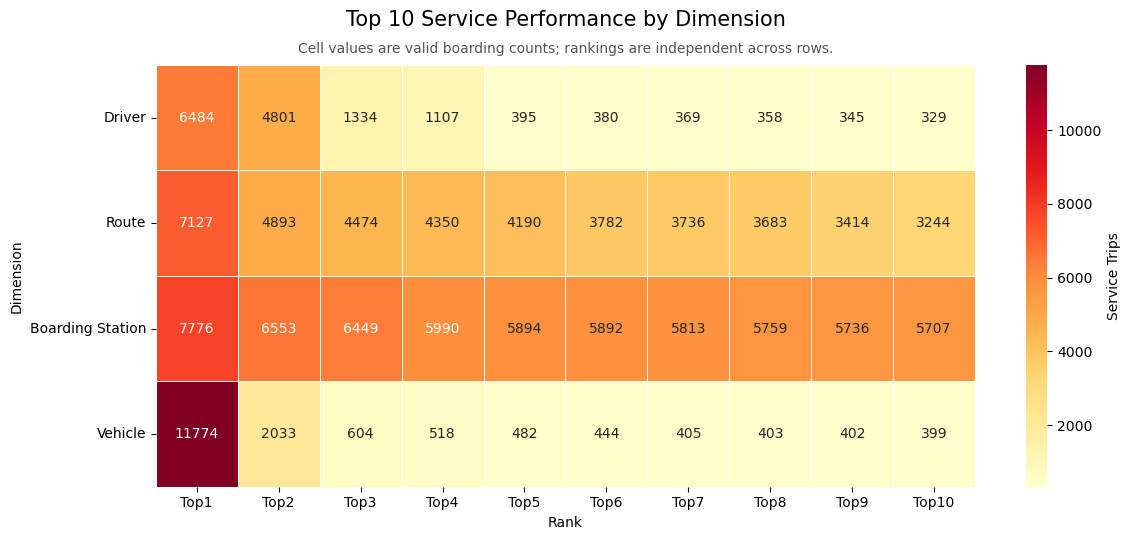

结论说明：
热力图显示，客流在不同服务维度上并不均衡：Top1线路46003共服务7127人次，约为Top10线路的2.20倍；Top1司机0服务6484人次，Top1上车站点1有7776人次，Top1车辆0承载11774人次。线路和车辆的头部值明显高于同组后几名，说明少数核心运营对象承担了较集中的服务量，后续排班和运力配置应重点关注这些高负荷对象。


In [7]:
def analyze_service_performance(boardings):
    """计算四个服务维度的 Top 10，并绘制 4×10 热力图。"""
    print_task_title(6, "服务绩效排名与热力图")

    ranking_columns = {
        "Driver": "驾驶员编号",
        "Route": "线路号",
        "Boarding Station": "上车站点",
        "Vehicle": "车辆编号",
    }
    rankings = {
        dimension: boardings[column].value_counts().head(10)
        for dimension, column in ranking_columns.items()
    }

    for dimension, ranking in rankings.items():
        print(f"\n{dimension} Top 10：")
        for rank, (entity, count) in enumerate(ranking.items(), start=1):
            print(f"Top{rank:>2}  {int(entity):>6}: {int(count)} 次")

    heatmap_values = np.vstack(
        [rankings[dimension].to_numpy(dtype=int) for dimension in ranking_columns]
    )
    heatmap_data = pd.DataFrame(
        heatmap_values,
        index=list(ranking_columns.keys()),
        columns=[f"Top{i}" for i in range(1, 11)],
    )

    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlOrRd",
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": "Service Trips"},
        ax=ax,
    )
    ax.set_title("Top 10 Service Performance by Dimension", fontsize=15, pad=28)
    ax.text(
        0.5,
        1.02,
        "Cell values are valid boarding counts; rankings are independent across rows.",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        color="#555555",
    )
    ax.set_xlabel("Rank")
    ax.set_ylabel("Dimension")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    fig.tight_layout()
    output_path = PROJECT_DIR / "performance_heatmap.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"\n服务绩效热力图已保存：{output_path}")
    plt.show()
    plt.close(fig)

    top_driver, top_driver_count = rankings["Driver"].index[0], rankings["Driver"].iloc[0]
    top_route, top_route_count = rankings["Route"].index[0], rankings["Route"].iloc[0]
    tenth_route_count = rankings["Route"].iloc[-1]
    top_station, top_station_count = (
        rankings["Boarding Station"].index[0],
        rankings["Boarding Station"].iloc[0],
    )
    top_vehicle, top_vehicle_count = rankings["Vehicle"].index[0], rankings["Vehicle"].iloc[0]
    route_ratio = top_route_count / tenth_route_count
    conclusion = (
        f"热力图显示，客流在不同服务维度上并不均衡：Top1线路{int(top_route)}"
        f"共服务{int(top_route_count)}人次，约为Top10线路的{route_ratio:.2f}倍；"
        f"Top1司机{int(top_driver)}服务{int(top_driver_count)}人次，"
        f"Top1上车站点{int(top_station)}有{int(top_station_count)}人次，"
        f"Top1车辆{int(top_vehicle)}承载{int(top_vehicle_count)}人次。"
        "线路和车辆的头部值明显高于同组后几名，说明少数核心运营对象承担了较集中的服务量，"
        "后续排班和运力配置应重点关注这些高负荷对象。"
    )
    print("结论说明：")
    print(conclusion)
    return rankings, heatmap_data, conclusion




rankings, heatmap_data, conclusion = analyze_service_performance(boardings)

## 结果小结

全部六项任务已顺序执行；图片和路线驾驶员文件同时保存在项目根目录。